In [2]:
import torch
from torch import nn
from d2l import torch as d2l

LeNet, AlexNet, and VGG all share a common design pattern: extract features exploiting spatial structure via a sequence of convolutions and pooling layers and post-process the representations via fully connected layers. The improvements upon LeNet by AlexNet and VGG mainly lie in how these later networks widen and deepen these two modules.

This design poses two major challenges. First, the fully connected layers at the end of the architecture consume tremendous numbers of parameters. For instance, even a simple model such as VGG-11 requires a monstrous matrix, occupying almost 400MB of RAM in single precision (FP32). This is a significant impediment to computation, in particular on mobile and embedded devices. After all, even high-end mobile phones sport no more than 8GB of RAM. At the time VGG was invented, this was an order of magnitude less (the iPhone 4S had 512MB). As such, it would have been difficult to justify spending the majority of memory on an image classifier.

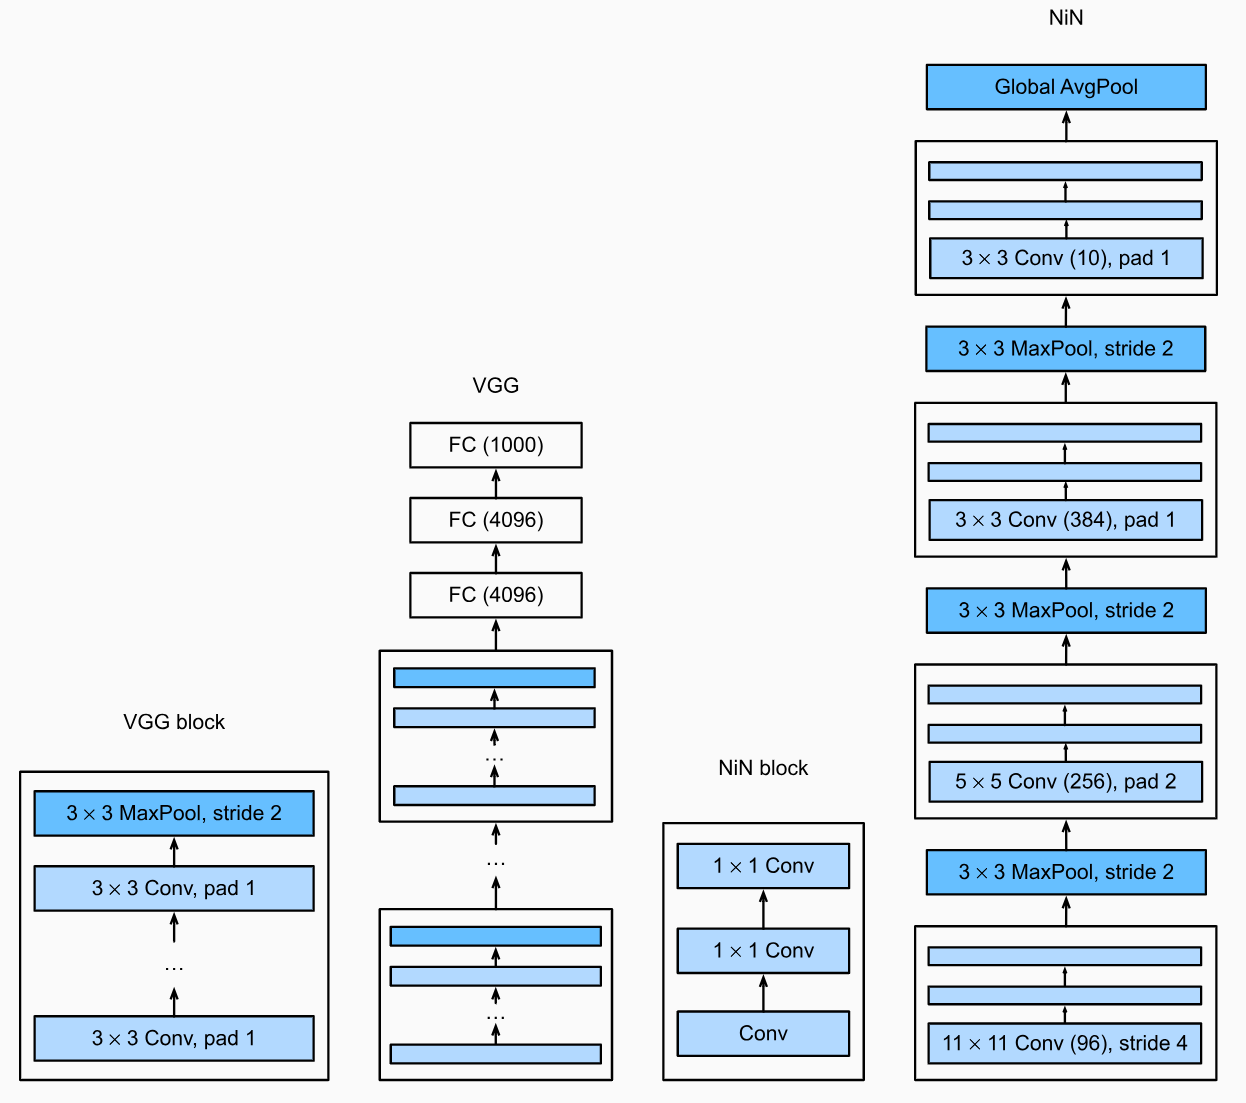

In [3]:
def nin_block(out_channels, kernel_size, stride, padding):
    return nn.Sequential(
        nn.LazyConv2d(out_channels, kernel_size, stride, padding), nn.ReLU(),
        nn.LazyConv2d(out_channels, kernel_size=1), nn.ReLU(),
        nn.LazyConv2d(out_channels, kernel_size=1), nn.ReLU(),
    )

In [ ]:
class NiN(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nin_block(96, kernel_size=11, stride=4, padding=0),
            nn.MaxPool2d(3, stride=2),
            nin_block(256, kernel_size=5, stride=1, padding=2),
            nn.MaxPool2d(3, stride=2),
            nin_block(384, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(3, stride=2),
            nn.Dropout(0.5),
            nin_block(num_classes, kernel_size=3, stride=1, padding=1), #NiN does not have any fully connected layers - reducing the number of parameters
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten()
        )
        self.net.apply(d2l.init_cnn)

In [7]:
NiN().layer_summary((1,1,224,224))

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


In [ ]:
model = NiN(lr=0.05)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(224, 224))
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)